# Task multi-label training

Trains a single multi-label model on the 4-class task dataset (3 target
species + `non_target`). Outputs are independent sigmoids — a clip can
fire more than one class at a time, which matches reality (multiple birds
can be present in the same window). Decisions are per-class above
`THRESHOLD` rather than argmax.

Metrics: per-class precision/recall/F1/F2 at threshold, macro averages,
subset (exact-match) accuracy, one-vs-rest ROC/AUC, per-class prediction
rates by true class.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import os

import pyrootutils

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

ROOT = pyrootutils.setup_root(
    search_from=Path.cwd(),
    indicator="pyproject.toml",
    pythonpath=True,
    dotenv=True,
)

## Parameters

In [3]:
# COLLECTION is the on-disk dataset folder name produced by
# dataset_build.ipynb — i.e. task_slug(TARGET_SPECIES, LAT, LON, RADIUS_KM).
COLLECTION = "task_s3_49_2_r50"
BUILD_MODEL = "sincnet"  # one of: mel_cnn, mel_cnn_2, cnn1d, sincnet, leaf, transformer, squeezenet_mel, squeezenet_time
EPOCHS = 100
PATIENCE = 10
BATCH_SIZE = 16
SEED = 42
THRESHOLD = 0.5  # per-class decision threshold for the multi-label metrics
NON_TARGET_NAME = "non_target"

# Results: one folder per (species, area) experiment, with one JSON per run.
RUN_NAME = BUILD_MODEL
RESULTS_FILE = ROOT / "results" / COLLECTION / f"{RUN_NAME}.json"
MODEL_PATH = ROOT / "models" / COLLECTION / f"{BUILD_MODEL}.keras"

## Load dataset catalog

Uses the same per-class cached waveform catalog that `scaling.py` builds. The
first run populates `.cache/<collection>/waveform_<hash>/` for each split; later
runs hit the cache directly.

In [4]:
import logging
import warnings

import numpy as np
import tensorflow as tf

tf.get_logger().setLevel("ERROR")
logging.getLogger("absl").setLevel("ERROR")
warnings.filterwarnings("ignore", message=".*AudioResample.*")

from building.scaling import (
    build_dataset_from_catalog,
    collect_predictions,
    compute_metrics,
    load_dataset_catalog,
    model_factory,
)
from building.models import input_repr_for

catalog = load_dataset_catalog(COLLECTION)

non_target_idx = catalog.class_names.index(NON_TARGET_NAME)
target_idxs = [i for i, n in enumerate(catalog.class_names) if n != NON_TARGET_NAME]
final_labels = [catalog.class_names[i] for i in target_idxs] + [NON_TARGET_NAME]
print(f"target_idxs={target_idxs}  non_target_idx={non_target_idx}")
print(f"final label order: {final_labels}")

  caching training/Emberiza_calandra ... 5600 samples
  caching validation/Emberiza_calandra ... 1200 samples
  caching testing/Emberiza_calandra ... 1200 samples
  caching training/Hippolais_polyglotta ... 5431 samples
  caching validation/Hippolais_polyglotta ... 1163 samples
  caching testing/Hippolais_polyglotta ... 1165 samples
  caching training/Regulus_ignicapilla ... 5600 samples
  caching validation/Regulus_ignicapilla ... 1200 samples
  caching testing/Regulus_ignicapilla ... 1200 samples
  caching training/non_target ... 17912 samples
  caching validation/non_target ... 3835 samples
  caching testing/non_target ... 3847 samples
target_idxs=[0, 1, 2]  non_target_idx=3
final label order: ['Emberiza_calandra', 'Hippolais_polyglotta', 'Regulus_ignicapilla', 'non_target']


In [5]:
import pandas as pd

counts = pd.DataFrame(
    [(e.name, e.train.count, e.val.count, e.test.count) for e in catalog.entries],
    columns=["class", "train", "val", "test"],
).set_index("class")
counts["total"] = counts.sum(axis=1)
counts.loc["TOTAL"] = counts.sum(axis=0)

(
    counts.style
    .background_gradient(cmap="Blues", subset=(counts.index[:-1], ["train", "val", "test"]))
    .format("{:,}")
    .set_caption(f"Sample counts per class × split  ({COLLECTION})")
    .set_table_styles([
        {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "110%"), ("padding", "6px 0")]},
        {"selector": "th", "props": [("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "right"), ("padding", "4px 10px")]},
    ])
)

,train,val,test,total
class,,,,
Emberiza_calandra,"5,600","1,200","1,200","8,000"
Hippolais_polyglotta,"5,431","1,163","1,165","7,759"
Regulus_ignicapilla,"5,600","1,200","1,200","8,000"
non_target,"17,912","3,835","3,847","25,594"
TOTAL,"34,543","7,398","7,412","49,353"


## Build train/val/test pipelines

`build_dataset_from_catalog` shuffles each class independently, repeats, and
mixes via `sample_from_datasets` so every training batch is class-balanced
regardless of class size. Validation/test use the natural distribution.

In [6]:
input_repr = input_repr_for(BUILD_MODEL)
rng = np.random.default_rng(SEED)

train_ds, meta = build_dataset_from_catalog(
    catalog, target_idxs, non_target_idx, BATCH_SIZE, rng,
    split="train", input_repr=input_repr, augment=True,
)
val_ds, _ = build_dataset_from_catalog(
    catalog, target_idxs, non_target_idx, BATCH_SIZE, rng,
    split="val", input_repr=input_repr, augment=False,
)
test_ds, _ = build_dataset_from_catalog(
    catalog, target_idxs, non_target_idx, BATCH_SIZE, rng,
    split="test", input_repr=input_repr, augment=False,
)
print(f"n_classes={meta.n_classes}  epoch_samples={meta.epoch_samples}")
print("class_weights:")
for lbl, w in meta.class_weights.items():
    print(f"  {final_labels[lbl]:<24s} {w:.3f}")

n_classes=4  epoch_samples=34543
class_weights:
  Emberiza_calandra        1.196
  Hippolais_polyglotta     1.233
  Regulus_ignicapilla      1.196
  non_target               0.374


## Build model and train

In [7]:
tf.keras.backend.clear_session()
model = model_factory(BUILD_MODEL)(meta.n_classes)
model.summary()

Model: "sincnet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ audio (InputLayer)              │ (None, 48000, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ to_nhwc (Reshape)               │ (None, 48000, 1, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sincnet_convolution             │ (None, 2996, 1, 32)    │            64 │
│ (SincnetConv)                   │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 2996, 1, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ envelope_pool                   │ (None, 749, 1, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_conv_1 (Conv2D)        │ (None, 375, 1, 16)     │         4,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 375, 1, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_pool_1                 │ (None, 93, 1, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_conv_2 (Conv2D)        │ (None, 47, 1, 16)      │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 47, 1, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ final_pool (AveragePooling2D)   │ (None, 1, 1, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_pre_dense (Dropout)     │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_post_dense (Dropout)    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,588 (29.64 KB)

 Trainable params: 7,588 (29.64 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=2,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            restore_best_weights=True,
        ),
    ],
)
print(f"Stopped after {len(history.history['loss'])} epochs")

Epoch 1/100
2159/2159 - 85s - 39ms/step - accuracy: 0.5679 - loss: 0.3266 - precision: 0.7502 - recall: 0.3703 - val_accuracy: 0.6649 - val_loss: 0.2440 - val_precision: 0.7255 - val_recall: 0.6073
Epoch 2/100
2159/2159 - 77s - 35ms/step - accuracy: 0.6537 - loss: 0.2470 - precision: 0.7201 - recall: 0.5746 - val_accuracy: 0.7217 - val_loss: 0.2029 - val_precision: 0.7801 - val_recall: 0.6642
Epoch 3/100
2159/2159 - 71s - 33ms/step - accuracy: 0.6832 - loss: 0.2223 - precision: 0.7472 - recall: 0.6163 - val_accuracy: 0.7252 - val_loss: 0.1898 - val_precision: 0.7680 - val_recall: 0.6565
Epoch 4/100
2159/2159 - 71s - 33ms/step - accuracy: 0.6969 - loss: 0.2131 - precision: 0.7561 - recall: 0.6288 - val_accuracy: 0.7217 - val_loss: 0.1901 - val_precision: 0.7669 - val_recall: 0.6761
Epoch 5/100
2159/2159 - 77s - 35ms/step - accuracy: 0.7098 - loss: 0.2059 - precision: 0.7655 - recall: 0.6418 - val_accuracy: 0.7359 - val_loss: 0.1814 - val_precision: 0.7670 - val_recall: 0.6872
Epoch 6/10

## Training curves

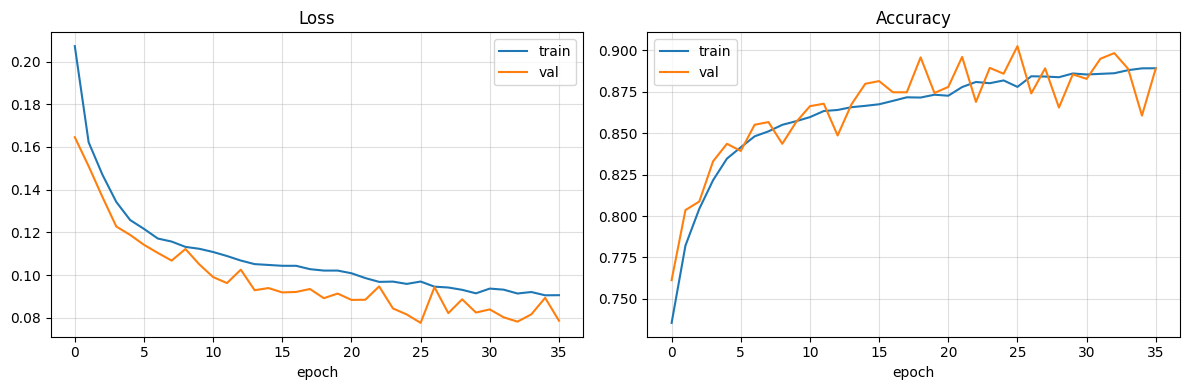

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(alpha=0.4)

acc_key = next(
    (k for k in ("accuracy", "categorical_accuracy") if k in history.history),
    None,
)
if acc_key is not None:
    axes[1].plot(history.history[acc_key], label="train")
    axes[1].plot(history.history[f"val_{acc_key}"], label="val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    axes[1].grid(alpha=0.4)
plt.tight_layout()
plt.show()

## Post-training quantization + save

Bake the float model to an INT8 `.tflite` (calibrated on `val_ds`), run both backends on `test_ds`, then persist:

- `models/<collection>/<run>.keras` — float model
- `models/<collection>/<run>.tflite` — INT8 model
- `results/<collection>/<run>.json`  — schema-v2 record (metrics + deltas + sampled curves)
- `results/<collection>/<run>.npz`   — y_true / y_score_float / y_score_quant + per-class ROC & sweep arrays

Per-species tables, ROC, threshold sweeps and the float-vs-INT8 visualisations are in **`results.ipynb`**: it loads these files via `results_io.load_run()` and rerenders every display without retraining.

In [ ]:
from building.models.bake import bake_model, default_tflite_path
from building.models import model_eval as M
from building import results_io as R

tflite_path = default_tflite_path(BUILD_MODEL, COLLECTION)
tflite_stats = bake_model(model, val_ds, tflite_path, n_representative=100)
print(f'Wrote INT8 .tflite → {tflite_path}')

Saved artifact at '/tmp/tmp0n7ugkli'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 184, 80, 1), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(1, 4), dtype=tf.float32, name=None)
Captures:
  123410050419408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123415003023504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123409784649680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123413809132560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123413809127376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123416896174608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123415003030800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123415003033680: TensorSpec(shape=(), dtype=tf.resource, name=None)
Baked INT8 TFLite -> /home/nathan/Documents/multi-chirp/models/task_s3_49_2_r50/mel_cnn.tflite
  flash (weights)  :     25.2 KB
  est. MFLOPs      :    0.349
  input shape/d

W0000 00:00:1779366533.270889    8864 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1779366533.270904    8864 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


In [ ]:
cmp = M.compare_float_vs_quantized(
    model, tflite_path, test_ds, final_labels,
    threshold=THRESHOLD, threshold_mode='fixed',
    non_target_names=[NON_TARGET_NAME],
)
y_true = cmp.float_eval.y_true
test_loss_float = float(
    tf.keras.losses.BinaryCrossentropy()(y_true, cmp.float_eval.y_score).numpy()
)
test_loss_quant = float(
    tf.keras.losses.BinaryCrossentropy()(y_true, cmp.quant_eval.y_score).numpy()
)
qe = cmp.quant_eval
print(
    f'INT8 macro-targets — '
    f'precision={qe.macro_precision_targets:.4f}  '
    f'recall={qe.macro_recall_targets:.4f}  '
    f'F1={qe.macro_f1_targets:.4f}  '
    f'F2={qe.macro_f2_targets:.4f}  '
    f'AUC={qe.macro_auc_targets:.4f}'
)
print(f'loss   float={test_loss_float:.4f}   int8={test_loss_quant:.4f}   Δ={test_loss_quant - test_loss_float:+.4f}')

INT8 macro-targets — precision=0.8444  recall=0.9524  F1=0.8951  F2=0.9286  AUC=0.9911
loss   float=0.1304   int8=0.1390   Δ=+0.0086


## Save model and results record

Float `.keras`, INT8 `.tflite`, summary `.json`, and an `.npz` sidecar carrying the raw `y_true / y_score_float / y_score_quant` plus per-species ROC + threshold-sweep arrays — enough to recompute any metric later without rerunning the model.

In [ ]:
model.save(MODEL_PATH)
print(f'Saved float : {MODEL_PATH}')
print(f'Saved INT8  : {tflite_path}')

record = R.RunRecord.from_comparison(
    cmp,
    non_target_names=[NON_TARGET_NAME],
    tflite_stats=tflite_stats,
    losses=(test_loss_float, test_loss_quant),
    collection=COLLECTION,
    run_name=RUN_NAME,
    build_model=BUILD_MODEL,
    epochs_trained=len(history.history['loss']),
    model_path=str(MODEL_PATH),
    tflite_path=str(tflite_path),
    hyperparams=dict(
        epochs=EPOCHS, patience=PATIENCE, batch_size=BATCH_SIZE,
        seed=SEED, threshold=THRESHOLD, input_repr=input_repr,
    ),
)
record.save(RESULTS_FILE)
print(f'Wrote JSON : {RESULTS_FILE}')
print(f'Wrote NPZ  : {RESULTS_FILE.with_suffix(".npz")}')
print('\nRender per-species tables + plots via building/geographic_task/results.ipynb.')

Saved float : /home/nathan/Documents/multi-chirp/models/task_s3_49_2_r50/mel_cnn.keras
Saved INT8  : /home/nathan/Documents/multi-chirp/models/task_s3_49_2_r50/mel_cnn.tflite
Wrote JSON : /home/nathan/Documents/multi-chirp/results/task_s3_49_2_r50/mel_cnn.json
Wrote NPZ  : /home/nathan/Documents/multi-chirp/results/task_s3_49_2_r50/mel_cnn.npz

Render per-species tables + plots via building/geographic_task/results.ipynb.


In [ ]:
from building.scaling import cleanup_waveform_cache

# Wipe the waveform cache: reclaims a few GB and forces the next run to
# rebuild from disk so any dataset edits are picked up automatically.
cleanup_waveform_cache(COLLECTION)

[cleanup] removed /home/nathan/Documents/multi-chirp/.cache/task_s3_49_2_r50 (9,477.3 MB freed)
